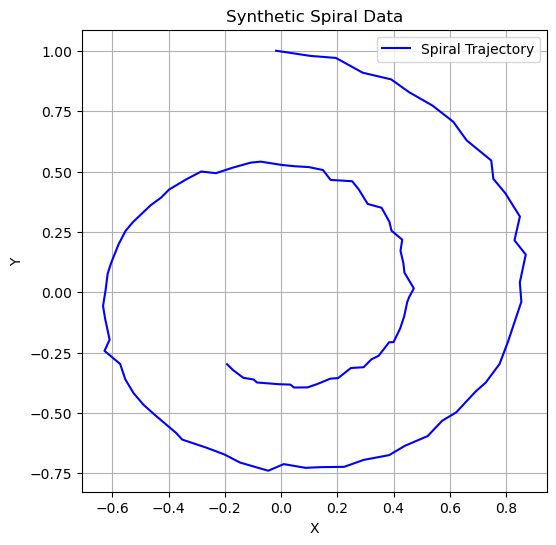

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate spiral trajectory data
def generate_spiral_data(t, noise_std=0.01):
    x = np.sin(t) * np.exp(-0.1 * t)
    y = np.cos(t) * np.exp(-0.1 * t)
    x += np.random.normal(0, noise_std, size=t.shape)
    y += np.random.normal(0, noise_std, size=t.shape)
    return np.stack([x, y], axis=1)

# Time points
t = np.linspace(0, 10, 100)
data = generate_spiral_data(t)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(data[:, 0], data[:, 1], label="Spiral Trajectory", color="blue")
plt.title("Synthetic Spiral Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.show()

In [3]:
conda install pytorch::pytorch

Channels:
 - defaults
 - pytorch
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/homebrew/anaconda3

  added / updated specs:
    - pytorch::pytorch


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    certifi-2025.6.15          |  py312hca03da5_0         157 KB
    pytorch-2.5.1              |         py3.12_0        59.2 MB  pytorch
    ------------------------------------------------------------
                                           Total:        59.4 MB

The following NEW packages will be INSTALLED:

  pytorch            pytorch/osx-arm64::pytorch-2.5.1-py3.12_0 

The following packages will be UPDATED:

  certifi                         2025.4.26-py312hca03da5_0 --> 2025.6.15-py312hca03da5_0 



pytorch-2.5.1        | 59.2 MB   |                                       |   0% 
certifi-2025.6.15    | 157 KB    |                         

In [4]:
import torch
import torch.nn as nn

class ODEFunc(nn.Module):
    def __init__(self):
        super(ODEFunc, self).__init__()
        # Neural network to model the dynamics
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 2)
        )

    def forward(self, t, y):
        return self.net(y)

In [6]:
conda install conda-forge::torchdiffeq

Channels:
 - defaults
 - conda-forge
 - pytorch
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/homebrew/anaconda3

  added / updated specs:
    - conda-forge::torchdiffeq


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    torchdiffeq-0.2.2          |     pyhd8ed1ab_0          28 KB  conda-forge
    ------------------------------------------------------------
                                           Total:          28 KB

The following NEW packages will be INSTALLED:

  torchdiffeq        conda-forge/noarch::torchdiffeq-0.2.2-pyhd8ed1ab_0 



                                                                                
Preparing transaction: done
Verifying transaction: | WARNING conda.core.path_actions:verify(1024): Unable to create environments file. Path not writable.
  environment location: /Users/ashwinbalaji/.conda/environments.txt

In [7]:
from torchdiffeq import odeint

# Define an example trajectory
ode_func = ODEFunc()
y0 = torch.tensor([1.0, 0.0])  # Initial state
t = torch.linspace(0, 10, 100)  # Time points

# Solve the ODE
predicted_trajectory = odeint(ode_func, y0, t)

print(predicted_trajectory.shape)  # Shape: [100, 2]

torch.Size([100, 2])


In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ode_func.parameters(), lr=0.01)

In [10]:
# Training loop
for epoch in range(1000):
    optimizer.zero_grad()
    predicted_trajectory = odeint(ode_func, y0, t)
    loss = criterion(predicted_trajectory, data)  # Replace true_trajectory with actual data
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

TypeError: 'int' object is not callable

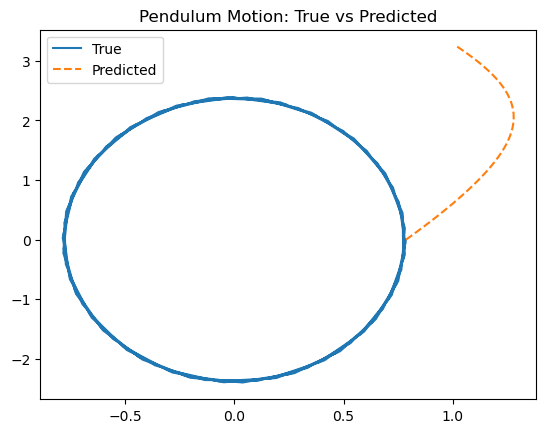

In [19]:
import torch
import torch.nn as nn
from torchdiffeq import odeint
import numpy as np
import matplotlib.pyplot as plt

# Simulate pendulum data
def pendulum_dynamics(t, y):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = -9.81 / 1.0 * np.sin(theta)
    return [dtheta_dt, domega_dt]

# Generate synthetic dataset
t = np.linspace(0, 10, 100)
y0 = [np.pi / 4, 0]  # Initial angle and velocity
from scipy.integrate import solve_ivp
solution = solve_ivp(pendulum_dynamics, [0, 10], y0, t_eval=t)

# Neural ODE model
class ODEFunc(nn.Module):
    def __init__(self):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 2)
        )

    def forward(self, t, y):
        return self.net(y)

# Model and solver setup
ode_func = ODEFunc()
y0 = torch.tensor([np.pi / 4, 0], dtype=torch.float32)
t = torch.linspace(0, 10, 100)
predicted_trajectory = odeint(ode_func, y0, t)

# Visualize
plt.plot(solution.y[0], solution.y[1], label="True")
plt.plot(predicted_trajectory[:, 0].detach().numpy(), predicted_trajectory[:, 1].detach().numpy(), label="Predicted", linestyle="--")
plt.legend()
plt.title("Pendulum Motion: True vs Predicted")
plt.show()